# Feb 19, 2026: resemblance to canonical systems

This is done with the survival mask of ROIs for each comm

conda env: gt

Change facet height to 0.5 while analyzing pi_1_aligned (higher level), while i.e. cols[0:1]. And to 0.35 while analyzing pi_0_aligned (lower level), i.e. while cols[1:2]

In [1]:
import csv
import os
import sys
import numpy as np
import pandas as pd
import scipy as sp 
import dill as pickle 
from os.path import join as pjoin
from itertools import product
from tqdm import tqdm
from copy import deepcopy
from pathlib import Path
import re
from scipy import stats

import glob
import random

from itertools import product, combinations
import multiprocessing as mp
from functools import partial
from joblib import Parallel, delayed

from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity
from munkres import Munkres

# networks
import graph_tool.all as gt

# plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.cm import rainbow
from cycler import cycler
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

plt.rcParamsDefault['font.family'] = "sans-serif"
plt.rcParamsDefault['font.sans-serif'] = "Arial"
plt.rcParams['font.size'] = 14
plt.rcParams["errorbar.capsize"] = 0.5

import colorcet as cc

# ignore user warnings
import warnings
warnings.filterwarnings("ignore") #, category=UserWarning)

In [2]:
def get_colorblind_palette(n=20):
    """Return a merged, deduplicated colorblind-safe palette from CUD, Seaborn, and extended sources."""
    base = [
        "#0072B2", "#D55E00", "#009E73", "#CC79A7",
        "#F0E442", "#56B4E9", "#E69F00", "#000000",
        "#999999", "#882255", "#44AA99", "#117733"
    ]
    
    new = [
        "#0173B2", "#DE8F05", "#029E73", "#D55E00",  # D55E00 already in base
        "#CC78BC", "#CA9161", "#FBAFE4", "#949494",
        "#ECE133", "#56B4E9"  # 56B4E9 already in base
    ]
    
    # Deduplicate while preserving order
    seen = set()
    full = base + new
    merged = []
    for color in full:
        if color.lower() not in seen:
            merged.append(color)
            seen.add(color.lower())
    
    return merged[:n]

def setup_mpl(fontsize=7):
    """Configure matplotlib for Illustrator export with Helvetica-style fonts and clean styles."""
    
    CUD_COLORS = get_colorblind_palette()
    
    mpl.rcParams.update({
        # Fonts and layout
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,

        # Export settings
        "svg.fonttype": 'none',
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "text.usetex": False,

        # Axes and ticks
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.5,
        "ytick.minor.width": 0.5,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,

        # Lines
        "lines.linewidth": 1.0,

        # Default color cycle (Color Universal Design)
        "axes.prop_cycle": cycler('color', CUD_COLORS),
    })

    # mpl.rcParams["axes.prop_cycle"] = cycler('color', get_colorblind_palette())

In [3]:
setup_mpl(fontsize=7)
CUD_COLORS = get_colorblind_palette()

In [4]:
import seaborn as sns

In [5]:
class ARGS():
    pass

args = ARGS()

args.SEED = 100

In [6]:
args.source = 'allen' #'spatial' #'allen'
args.space = 'ccfv2' #'ccfv2'
args.brain_div = 'whl' #'whl'
args.num_rois = 172 #162 #172
args.resolution = 200 #200

PARC_DESC = (
    f'source-{args.source}'
    f'_space-{args.space}'
    f'_braindiv-{args.brain_div}'
    f'_nrois-{args.num_rois}'
    f'_res-{args.resolution}'
)
PARC_DESC

'source-allen_space-ccfv2_braindiv-whl_nrois-172_res-200'

In [7]:
args.GRAPH_DEF = f'constructed'
args.GRAPH_METHOD = f'pearson'
args.THRESHOLD = f'signed'
args.EDGE_DEF = f'binary'
args.EDGE_DENSITY = 20
args.LAYER_DEF = f'individual'
args.DATA_UNIT = f'grp'

BASE_path = f'{os.environ["HOME"]}/new_mouse_dataset'
PARCELS_path = f'{BASE_path}/parcels'
ROI_path = (
    f'{BASE_path}/roi-results-v3'
    f'/{PARC_DESC}'
)
TS_path = f'{ROI_path}/roi_timeseries'

In [8]:
ROI_RESULTS_path = (
    f'{ROI_path}'
    f'/graph-{args.GRAPH_DEF}/method-{args.GRAPH_METHOD}'
    f'/threshold-{args.THRESHOLD}/edge-{args.EDGE_DEF}/density-{args.EDGE_DENSITY}'
    f'/layer-{args.LAYER_DEF}/unit-{args.DATA_UNIT}'
)
GRAPH_path = f'{ROI_RESULTS_path}/graphs'
os.system(f'mkdir -p {GRAPH_path}')
SBM_path = f'{ROI_RESULTS_path}/model-fits'
os.system(f'mkdir -p {SBM_path}')
DIAG_path = f'{ROI_RESULTS_path}/diagnostics'
os.system(f'mkdir -p {DIAG_path}')
ESTIM_path = f'{ROI_RESULTS_path}/estimates'
os.system(f'mkdir -p {ESTIM_path}/individual')
os.system(f'mkdir -p {ESTIM_path}/group')

0

In [9]:
ROI_RESULTS_path_boot = (
    f'{ROI_path}'
    f'/graph-{args.GRAPH_DEF}/method-{args.GRAPH_METHOD}'
    f'/threshold-{args.THRESHOLD}/edge-{args.EDGE_DEF}/density-{args.EDGE_DENSITY}'
    f'/layer-{args.LAYER_DEF}/unit-{args.DATA_UNIT}-boot'
)
GRAPH_path_boot = f'{ROI_RESULTS_path_boot}/graphs'
os.system(f'mkdir -p {GRAPH_path_boot}')
SBM_path_boot = f'{ROI_RESULTS_path_boot}/model-fits'
os.system(f'mkdir -p {SBM_path_boot}')
DIAG_path_boot = f'{ROI_RESULTS_path_boot}/diagnostics'
os.system(f'mkdir -p {DIAG_path_boot}')
ESTIM_path_boot = f'{ROI_RESULTS_path_boot}/estimates'
os.system(f'mkdir -p {ESTIM_path_boot}/individual')
os.system(f'mkdir -p {ESTIM_path_boot}/group')

0

In [10]:
args.dc, args.sbm = False, 'h'
args.nested = args.sbm == 'h'

args.force_niter = 100000
args.num_draws = int((1/2) * args.force_niter)

args.epsilon = 0.4 # threshold KSD for convergence
args.delta = np.ceil(args.force_niter / 100).astype(int)

def sbm_name(args):
    dc = f'dc' if args.dc else f'nd'
    dc = f'' if args.sbm in ['a', 'm'] else dc
    file = f'sbm-{dc}-{args.sbm}'
    return file

SBM = sbm_name(args)
SBM

'sbm-nd-h'

load membership matrices

In [11]:
args.method = 'hierarchical'

In [12]:
folder = f'{ESTIM_path}/group/multiplicity/partition/{SBM}'
os.makedirs(folder, exist_ok=True)

with open(f'{folder}/method-{args.method}_desc-merged-pis.pkl', 'rb') as f:
    merged_pis_df = pickle.load(f)

In [13]:
merged_pis_df

,sub,sbm,omega,pi,sil
0,00,sbm-nd-h,0.500108,"[[0.041480992414466955, 0.004175084175084179, ...",k ...
1,00,sbm-nd-h,0.191246,"[[0.8747844827586206, 0.0, 0.10215517241379313...",k ...
2,00,sbm-nd-h,0.142725,"[[0.8483659885452678, 0.0, 0.09019733848686834...",k ...
3,00,sbm-nd-h,0.132811,"[[0.8459903242342689, 0.008472375135437415, 0....",k ...
4,00,sbm-nd-h,0.031086,"[[0.45227272727272727, 0.0, 0.4727272727272727...",k ...
...,...,...,...,...,...
565,grp,sbm-nd-h,0.683759,"[[0.8959045802766508, 0.0, 0.0442791282701433,...",k labels ...
566,grp,sbm-nd-h,0.152146,"[[0.8647741147741148, 0.019230769230769232, 0....",k labels ...
567,grp,sbm-nd-h,0.071034,"[[0.04225352112676056, 0.16901408450704225, 0....",k labels ...
568,grp,sbm-nd-h,0.057237,"[[0.23105590062111803, 0.14285714285714285, 0....",k labels ...


load survived mask

In [14]:
folder = f'{ESTIM_path}/group/multiplicity/partition/{SBM}'
os.makedirs(folder, exist_ok=True)

level = 1

with open(f'{folder}/level-{level}_desc-median+survived-rois.pkl', 'rb') as f:
    [median_pi, survived_pi] = pickle.load(f)

In [15]:
merged_pis_df['pi'] = merged_pis_df['pi'].map(lambda Y: Y * survived_pi)

load canonical systems

In [16]:
ROI_SYS_path = f'{ROI_path}/canonical-systems/joanes'
X = np.loadtxt(f'{ROI_SYS_path}/desc-roi-rsns-mat.csv') # n_rois x n_rsns
v = np.loadtxt(f'{ROI_SYS_path}/desc-roi-vox-counts.csv') # n_rois
num_sys = X.shape[1]
num_sys

6

specificity

In [17]:
def specificity_matrix(X, Y, v):
    Yv = Y * v[:, np.newaxis]
    numerator = X.T @ Yv 
    denominator = Yv.sum(axis=0)
    S = numerator / denominator
    S = np.nan_to_num(S)
    S = np.round(S, decimals=3)
    return S

In [18]:
specificity_df = pd.concat(
    [
        merged_pis_df[['sub', 'sbm', 'omega']],
        merged_pis_df['pi'].map(lambda Y: specificity_matrix(X, Y, v))
    ],
    axis=1,
)

In [19]:
specificity_df

,sub,sbm,omega,pi
0,00,sbm-nd-h,0.500108,"[[0.0, 0.978, 0.067, 0.029, 0.0, 0.0, 0.0, 0.0..."
1,00,sbm-nd-h,0.191246,"[[0.0, 0.974, 0.067, 0.003, 0.0, 0.0, 0.0, 0.0..."
2,00,sbm-nd-h,0.142725,"[[0.0, 0.959, 0.069, 0.012, 0.0, 0.0, 0.0, 0.0..."
3,00,sbm-nd-h,0.132811,"[[0.0, 0.972, 0.068, 0.02, 0.0, 0.0, 0.0, 0.0,..."
4,00,sbm-nd-h,0.031086,"[[0.0, 0.97, 0.068, 0.022, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...,...
565,grp,sbm-nd-h,0.683759,"[[0.0, 0.956, 0.069, 0.032, 0.0, 0.0, 0.0, 0.0..."
566,grp,sbm-nd-h,0.152146,"[[0.0, 0.952, 0.066, 0.033, 0.0, 0.0, 0.0, 0.0..."
567,grp,sbm-nd-h,0.071034,"[[0.0, 0.955, 0.072, 0.034, 0.0, 0.0, 0.0, 0.0..."
568,grp,sbm-nd-h,0.057237,"[[0.0, 0.954, 0.068, 0.028, 0.0, 0.0, 0.0, 0.0..."


In [20]:
def get_soft_estim_df(estim_df: pd.DataFrame):
    soft_estim_df = []
    for sub, group in estim_df.groupby('sub'):
        omegas = group['omega']
        dct = {'sub':[sub], 'sbm':[SBM]}
        for col in ['pi']:
            X = group[col].to_list()
            soft_X = np.average(X, axis=0, weights=omegas)
            dct[col] = [soft_X]
        soft_estim_df += [pd.DataFrame(dct)]
    soft_estim_df = pd.concat(soft_estim_df).reset_index(drop=True)
    return soft_estim_df

In [21]:
soft_specificity_df = get_soft_estim_df(specificity_df)
soft_specificity_df

,sub,sbm,pi
0,00,sbm-nd-h,"[[0.0, 0.9733784996999401, 0.06740076015203042..."
1,01,sbm-nd-h,"[[0.0, 0.942, 0.079, 0.021, 0.0, 0.0, 0.0, 0.0..."
2,02,sbm-nd-h,"[[0.0, 0.9535886057211442, 0.06652640128025605..."
3,03,sbm-nd-h,"[[0.0, 0.965953888, 0.06741689600000002, 0.005..."
4,04,sbm-nd-h,"[[0.0, 0.957, 0.062, 0.02, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...
176,84,sbm-nd-h,"[[0.0, 0.9368346335933854, 0.07063926118557044..."
177,85,sbm-nd-h,"[[0.0, 0.9872474915050969, 0.04840153241388501..."
178,87,sbm-nd-h,"[[0.0, 0.9687002200440088, 0.06888329665933188..."
179,89,sbm-nd-h,"[[0.0, 0.9611514933333333, 0.06930298666666666..."


In [22]:
def make_tidy(estim_df: pd.DataFrame, col: str):
    mats_list = []
    for idx, mat in enumerate(estim_df[col]):
        rs, cs = np.indices(mat.shape)
        temp_df = pd.DataFrame({
            'i':rs.flatten(),
            'j':cs.flatten(),
            'value':mat.flatten(),
            'sample':idx,
        })
        mats_list += [temp_df]
    long_df = pd.concat(mats_list, ignore_index=True)
    return long_df

In [23]:
def plot_specificities(long_df: pd.DataFrame):
    ncols = sorted(long_df['i'].unique())
    ncols = len(ncols)
    nrows = sorted(long_df['j'].unique())
    nrows = len(nrows)

    height = 0.5 #inches
    aspect = 1
    width = height * aspect

    fig_height = height * nrows
    fig_width = width * ncols

    fig, axs = plt.subplots(
        nrows, ncols, 
        figsize=(fig_width, fig_height), 
        sharey=True
    )
    # Manually set the spacing. Values are fractions of the figure dimensions.
    # This guarantees identical spacing for every figure you create this way.
    fig.subplots_adjust(
        left=0.1,    # Increase if y-axis labels are cut off
        right=0.9,   # Decrease if there's too much margin on the right
        bottom=0.1,  # Increase if x-axis labels are cut off
        top=0.9,     # Decrease if titles are cut off
        wspace=0.3, # Width between subplots
        hspace=0.3,   # Height between subplots
    )

    for (i, j), group in long_df.groupby(by=['i', 'j']):
        
        ax = axs[j, i] if nrows > 1 else axs[i]
        
        sns.boxplot(
            group, 
            ax=ax,
            y='value',
            color='grey',
            fill=False,
            width=0.5,
            linewidth=1,
            fliersize=0,
            capprops=dict(linewidth=0),
        )
        
        sns.stripplot(
            group, 
            ax=ax, 
            y='value',
            color=CUD_COLORS[0],
            size=2,
            marker='o',
            alpha=0.5,
            jitter=True,
        )
        
        ax.grid(alpha=0.15)
        ax.set(ylim=[0, 1], yticks=[0, 1], )
        # ax.set(ylim=[0, 1], yticks=[0, 0.5, 1], xlabel=None, ylabel=None)
        if j == 0: ax.set_title(f'RSN {i+1}')
        if i == 0: ax.set_ylabel(f'C. {j+1:02d}')
        sns.despine(ax=ax, left=False, bottom=False, right=True, top=True)
    return fig

pi


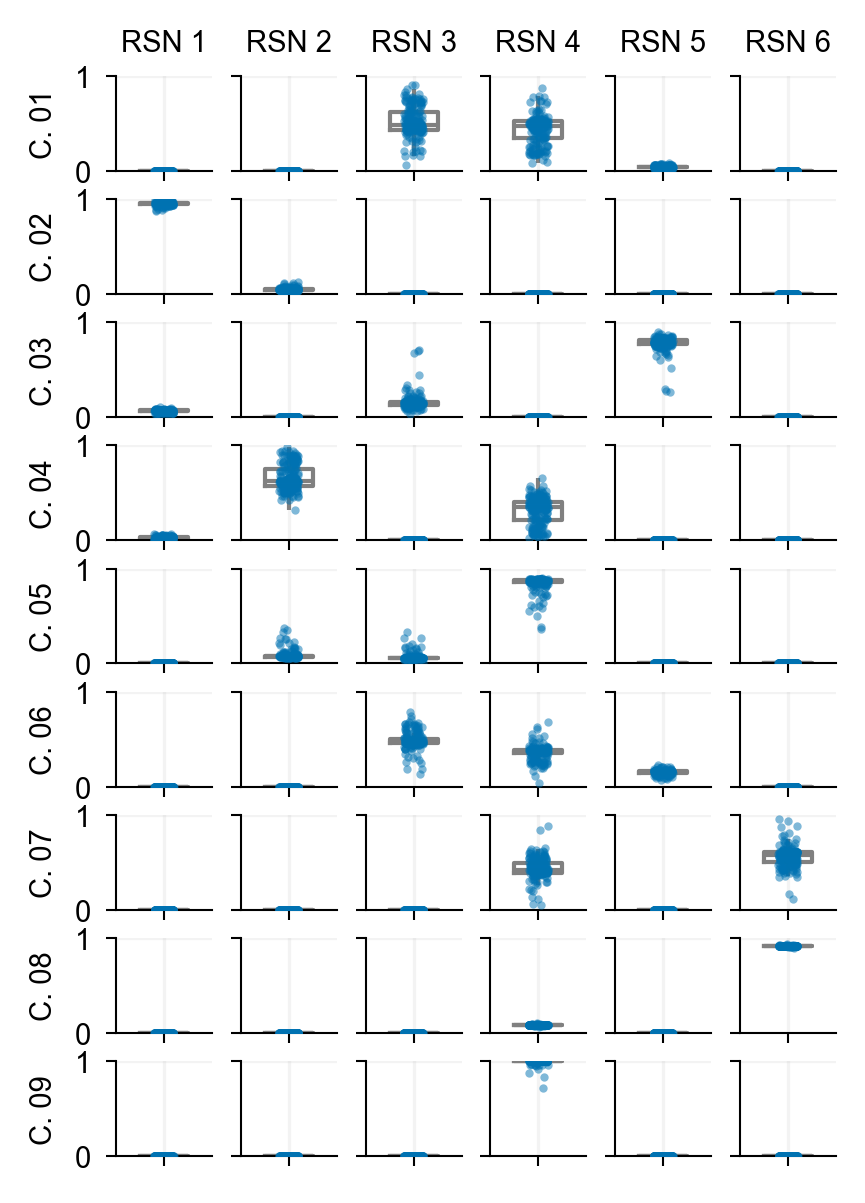

In [24]:
folder = f'{ESTIM_path}/group/resemblance-to-rsns/{SBM}'
os.makedirs(folder, exist_ok=True)

for col in ['pi']:
    print(col)
    level = 1 #col.replace('pi', '').replace('_', '').replace('aligned', '')
    long_df = make_tidy(soft_specificity_df, col)
    g = plot_specificities(long_df)
    g.savefig(f'{folder}/level-{level}_desc-specificities.svg', transparent=True, dpi=300, bbox_inches='tight')
    g.savefig(f'{folder}/level-{level}_desc-specificities.png', transparent=True, dpi=300, bbox_inches='tight')

effective number of RSNs spanned by a comm.

In [25]:
def eff_num_rsns(S):
    Ers = np.exp(stats.entropy(S, axis=0))
    Ers = np.nan_to_num(Ers)[None, :]
    return Ers

In [26]:
eff_num_rsns_df = pd.concat(
    [
        specificity_df[['sub', 'sbm', 'omega']],
        specificity_df['pi'].map(lambda S: eff_num_rsns(S)),
    ],
    axis=1,
)

soft_eff_num_rsns_df = get_soft_estim_df(eff_num_rsns_df)

soft_eff_num_rsns_df

,sub,sbm,pi
0,00,sbm-nd-h,"[[2.282247134551778, 1.1300752877103197, 1.925..."
1,01,sbm-nd-h,"[[2.28354209903062, 1.2478581675838785, 1.6674..."
2,02,sbm-nd-h,"[[2.2957011072437887, 1.2065832004670862, 1.97..."
3,03,sbm-nd-h,"[[1.9211483875570996, 1.1600923484081838, 1.95..."
4,04,sbm-nd-h,"[[2.2746089132654554, 1.1940654490129385, 1.77..."
...,...,...,...
176,84,sbm-nd-h,"[[2.1855151336153513, 1.2643470083972224, 1.87..."
177,85,sbm-nd-h,"[[2.1438843367127522, 1.069786555390323, 1.818..."
178,87,sbm-nd-h,"[[1.885993892242069, 1.1493425663998733, 1.902..."
179,89,sbm-nd-h,"[[2.246473380770285, 1.1785279359404865, 1.905..."


In [27]:
def plot_eff_num_rsns(long_df: pd.DataFrame, ):
    nrows = sorted(long_df['j'].unique())
    nrows = len(nrows)
    ncols = 1

    height = 0.5 #inches
    aspect = 1
    width = height * aspect

    fig_height = height * nrows
    fig_width = width * ncols

    fig, axs = plt.subplots(
        nrows, ncols, 
        figsize=(fig_width, fig_height), 
        sharey=False,
    )
    # Manually set the spacing. Values are fractions of the figure dimensions.
    # This guarantees identical spacing for every figure you create this way.
    fig.subplots_adjust(
        left=0.1,    # Increase if y-axis labels are cut off
        right=0.9,   # Decrease if there's too much margin on the right
        bottom=0.1,  # Increase if x-axis labels are cut off
        top=0.9,     # Decrease if titles are cut off
        wspace=0.3, # Width between subplots
        hspace=0.3,   # Height between subplots
    )

    for (i, j), group in long_df.groupby(by=['i', 'j']):
        
        ax = axs[j, i] if ncols > 1 else axs[j]
        
        sns.boxplot(
            group, 
            ax=ax,
            y='value',
            color='grey',
            fill=False,
            width=0.5,
            linewidth=1,
            fliersize=0,
            capprops=dict(linewidth=0),
        )
        
        sns.stripplot(
            group, 
            ax=ax, 
            y='value',
            color=CUD_COLORS[0],
            size=2,
            marker='o',
            alpha=0.5,
            jitter=True,
        )
        
        ax.grid(alpha=0.15)
        ax.set(ylabel=f'C. {j+1:02d}') #, ylim=[1, 5], yticks=[1, 2, 3, 4, 5], xlabel=None, ylabel=None)
        # ax.set(ylim=[1, 5], yticks=[1, 3, 5])
        sns.despine(ax=ax, left=False, bottom=False, right=True, top=True)
    return fig

pi


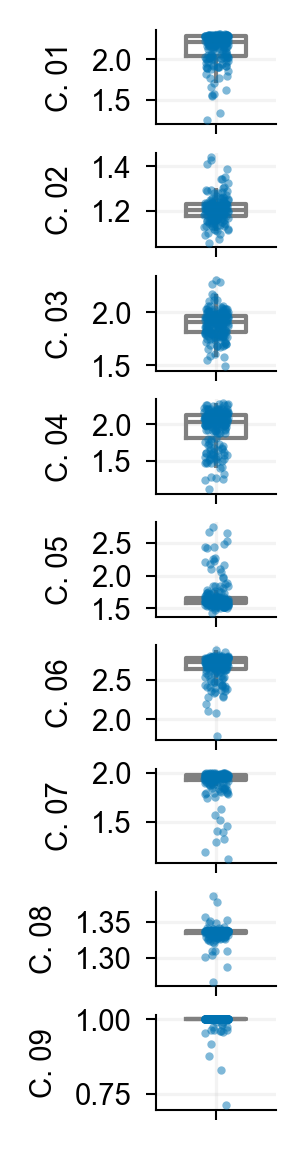

In [28]:
folder = f'{ESTIM_path}/group/resemblance-to-rsns/{SBM}'
os.makedirs(folder, exist_ok=True)

for col in ['pi']:
    print(col)
    level = 1 #col.replace('pi', '').replace('_', '').replace('aligned', '')
    long_df = make_tidy(soft_eff_num_rsns_df, col)
    g = plot_eff_num_rsns(long_df)
    g.savefig(f'{folder}/level-{level}_desc-eff-num-rsns.svg', transparent=True, dpi=300, bbox_inches='tight')
    g.savefig(f'{folder}/level-{level}_desc-eff-num-rsns.png', transparent=True, dpi=300, bbox_inches='tight')

coverage

In [29]:
def coverage_matrix(X, Y, v):
    Xv = X * v[:, np.newaxis]
    numerator = Y.T @ Xv 
    denominator = Xv.sum(axis=0)
    U = numerator / denominator
    U = np.nan_to_num(U)
    U = np.round(U, decimals=3)
    return U

In [30]:
coverage_df = pd.concat(
    [
        merged_pis_df[['sub', 'sbm', 'omega']],
        merged_pis_df['pi'].map(lambda Y: coverage_matrix(X, Y, v))
    ],
    axis=1,
)

In [31]:
coverage_df

,sub,sbm,omega,pi
0,00,sbm-nd-h,0.500108,"[[0.0, 0.0, 0.032, 0.016, 0.004, 0.0], [0.814,..."
1,00,sbm-nd-h,0.191246,"[[0.0, 0.0, 0.255, 0.061, 0.029, 0.0], [0.642,..."
2,00,sbm-nd-h,0.142725,"[[0.0, 0.0, 0.279, 0.094, 0.03, 0.0], [0.819, ..."
3,00,sbm-nd-h,0.132811,"[[0.0, 0.0, 0.274, 0.125, 0.035, 0.0], [0.723,..."
4,00,sbm-nd-h,0.031086,"[[0.0, 0.0, 0.211, 0.107, 0.03, 0.0], [0.698, ..."
...,...,...,...,...
565,grp,sbm-nd-h,0.683759,"[[0.0, 0.0, 0.299, 0.143, 0.04, 0.0], [0.799, ..."
566,grp,sbm-nd-h,0.152146,"[[0.0, 0.0, 0.29, 0.14, 0.039, 0.0], [0.777, 0..."
567,grp,sbm-nd-h,0.071034,"[[0.0, 0.0, 0.036, 0.019, 0.005, 0.0], [0.653,..."
568,grp,sbm-nd-h,0.057237,"[[0.0, 0.0, 0.18, 0.098, 0.027, 0.0], [0.74, 0..."


In [32]:
soft_coverage_df = get_soft_estim_df(coverage_df)
soft_coverage_df

,sub,sbm,pi
0,00,sbm-nd-h,"[[0.0, 0.0, 0.14818242048409683, 0.05331506301..."
1,01,sbm-nd-h,"[[0.0, 0.0, 0.071, 0.031, 0.008, 0.0], [0.411,..."
2,02,sbm-nd-h,"[[0.0, 0.0, 0.22625243448689739, 0.11572712942..."
3,03,sbm-nd-h,"[[0.0, 0.0, 0.05517482400000001, 0.10646161600..."
4,04,sbm-nd-h,"[[0.0, 0.0, 0.277, 0.092, 0.03, 0.0], [0.725, ..."
...,...,...,...
176,84,sbm-nd-h,"[[0.0, 0.0, 0.17590922184436888, 0.06316911382..."
177,85,sbm-nd-h,"[[0.0, 0.0, 0.13937601439136518, 0.03859320407..."
178,87,sbm-nd-h,"[[0.0, 0.0, 0.041157591518303664, 0.0533523104..."
179,89,sbm-nd-h,"[[0.0, 0.0, 0.21521050666666663, 0.07775602666..."


In [33]:
def plot_coverages(long_df: pd.DataFrame):
    ncols = sorted(long_df['i'].unique())
    ncols = len(ncols)
    nrows = sorted(long_df['j'].unique())
    nrows = len(nrows)

    height = 0.5 #inches
    aspect = 1
    width = height * aspect

    fig_height = height * nrows
    fig_width = width * ncols

    fig, axs = plt.subplots(
        nrows, ncols, 
        figsize=(fig_width, fig_height), 
        sharey=True
    )
    # Manually set the spacing. Values are fractions of the figure dimensions.
    # This guarantees identical spacing for every figure you create this way.
    fig.subplots_adjust(
        left=0.1,    # Increase if y-axis labels are cut off
        right=0.9,   # Decrease if there's too much margin on the right
        bottom=0.1,  # Increase if x-axis labels are cut off
        top=0.9,     # Decrease if titles are cut off
        wspace=0.3, # Width between subplots
        hspace=0.3,   # Height between subplots
    )

    for (i, j), group in long_df.groupby(by=['i', 'j']):
        
        ax = axs[j, i] if nrows > 1 else axs[i]
        
        sns.boxplot(
            group, 
            ax=ax,
            y='value',
            color='grey',
            fill=False,
            width=0.5,
            linewidth=1,
            fliersize=0,
            capprops=dict(linewidth=0),
        )
        
        sns.stripplot(
            group, 
            ax=ax, 
            y='value',
            color=CUD_COLORS[0],
            size=2,
            marker='o',
            alpha=0.5,
            jitter=True,
        )
        
        ax.grid(alpha=0.15)
        # ax.set(ylim=[0, 1], yticks=[0, 0.5, 1], xlabel=None, ylabel=None)
        ax.set(ylim=[0, 1], yticks=[0, 1])
        if j == 0: ax.set_title(f'C. {i+1:02d}')
        if i == 0: ax.set_ylabel(f'RSN {j+1}')
        sns.despine(ax=ax, left=False, bottom=False, right=True, top=True)
    return fig

pi


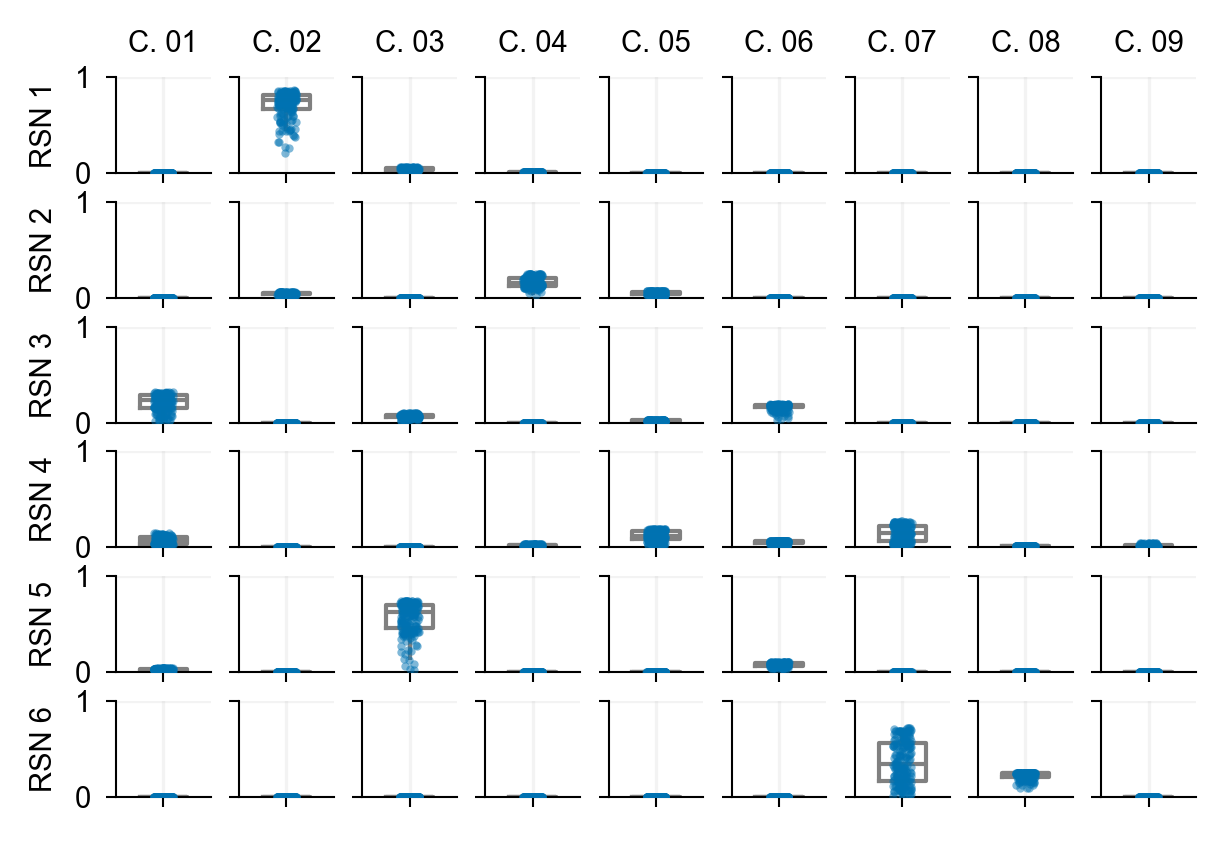

In [34]:
folder = f'{ESTIM_path}/group/resemblance-to-rsns/{SBM}'
os.makedirs(folder, exist_ok=True)

for col in ['pi']:
    print(col)
    level = 1 #col.replace('pi', '').replace('_', '').replace('aligned', '')
    long_df = make_tidy(soft_coverage_df, col)
    g = plot_coverages(long_df)
    g.savefig(f'{folder}/level-{level}_desc-coverages.svg', transparent=True, dpi=300, bbox_inches='tight')
    g.savefig(f'{folder}/level-{level}_desc-coverages.png', transparent=True, dpi=300, bbox_inches='tight')

effective number of comms. that cover an RSN

In [35]:
def eff_num_comms(U):
    Ers = np.exp(stats.entropy(U, axis=0))
    Ers = np.nan_to_num(Ers)[None, :]
    return Ers

In [36]:
eff_num_comms_df = pd.concat(
    [
        coverage_df[['sub', 'sbm', 'omega']],
        coverage_df['pi'].map(lambda U: eff_num_comms(U)),
    ],
    axis=1,
)

soft_eff_num_comms_df = get_soft_estim_df(eff_num_comms_df)

soft_eff_num_comms_df

,sub,sbm,pi
0,00,sbm-nd-h,"[[1.319236589339463, 2.207580189742056, 2.9608..."
1,01,sbm-nd-h,"[[1.4825073127851005, 2.299222144416899, 2.925..."
2,02,sbm-nd-h,"[[1.310235477934612, 2.679605065767394, 3.2018..."
3,03,sbm-nd-h,"[[1.2889131187638423, 2.295659078619988, 3.224..."
4,04,sbm-nd-h,"[[1.2314656537656135, 2.611928440119862, 2.686..."
...,...,...,...
176,84,sbm-nd-h,"[[1.5302665338024473, 2.4706030075237564, 2.67..."
177,85,sbm-nd-h,"[[1.2799907472316907, 1.947810944276585, 3.106..."
178,87,sbm-nd-h,"[[1.2829672391444793, 2.534386333794511, 3.166..."
179,89,sbm-nd-h,"[[1.311983415985646, 2.636198833221461, 2.9735..."


In [37]:
def plot_eff_num_comms(long_df: pd.DataFrame, ):
    nrows = sorted(long_df['j'].unique())
    nrows = len(nrows)
    ncols = 1

    height = 0.5 #inches
    aspect = 1
    width = height * aspect

    fig_height = height * nrows
    fig_width = width * ncols

    fig, axs = plt.subplots(
        nrows, ncols, 
        figsize=(fig_width, fig_height), 
        sharey=False,
    )
    # Manually set the spacing. Values are fractions of the figure dimensions.
    # This guarantees identical spacing for every figure you create this way.
    fig.subplots_adjust(
        left=0.1,    # Increase if y-axis labels are cut off
        right=0.9,   # Decrease if there's too much margin on the right
        bottom=0.1,  # Increase if x-axis labels are cut off
        top=0.9,     # Decrease if titles are cut off
        wspace=0.3, # Width between subplots
        hspace=0.3,   # Height between subplots
    )

    for (i, j), group in long_df.groupby(by=['i', 'j']):
        
        ax = axs[j, i] if ncols > 1 else axs[j]
        
        sns.boxplot(
            group, 
            ax=ax,
            y='value',
            color='grey',
            fill=False,
            width=0.5,
            linewidth=1,
            fliersize=0,
            capprops=dict(linewidth=0),
        )
        
        sns.stripplot(
            group, 
            ax=ax, 
            y='value',
            color=CUD_COLORS[0],
            size=2,
            marker='o',
            alpha=0.5,
            jitter=True,
        )
        
        ax.grid(alpha=0.15)
        ax.set(ylabel=f'RSN {j+1}') 
        sns.despine(ax=ax, left=False, bottom=False, right=True, top=True)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3, prune='both')) # Limits to ~3 ticks
    return fig

pi


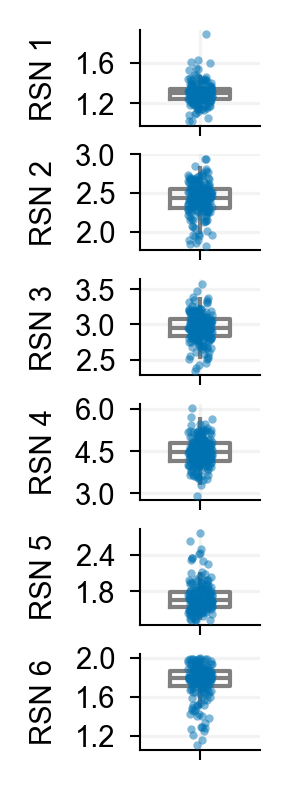

In [38]:
folder = f'{ESTIM_path}/group/resemblance-to-rsns/{SBM}'
os.makedirs(folder, exist_ok=True)

for col in ['pi']:
    print(col)
    level = 1 #col.replace('pi', '').replace('_', '').replace('aligned', '')
    long_df = make_tidy(soft_eff_num_comms_df, col)
    g = plot_eff_num_comms(long_df)
    g.savefig(f'{folder}/level-{level}_desc-eff-num-comms.svg', transparent=True, dpi=300, bbox_inches='tight')
    g.savefig(f'{folder}/level-{level}_desc-eff-num-comms.png', transparent=True, dpi=300, bbox_inches='tight')